## Calcul des Statistiques descriptives 
### Médiane, Moyenne, Ecart-type, Quartile

In [5]:
import sys
sys.path.append(r"C:\Users\GLC\OneDrive\Documents\DATA-IA\Projet1_Nexacom\src\projet1_nexacom")


import pandas as pd
from data_loader import load_csv
from unidecode import unidecode ### Pour que yaounde et yaoundé soit pareils

df_orders = pd.DataFrame(load_csv(r"C:\Users\GLC\OneDrive\Documents\DATA-IA\Projet1_Nexacom\data\orders.csv"))### Charger les fichiers csv 
df_orders["delivery_time_min"] = pd.to_numeric(df_orders["delivery_time_min"], errors="coerce")

### Pour que l'algo prenne en compte les espaces et les majuscules
df_orders["city"] = df_orders["city"].str.strip().str.title().apply(unidecode)


### La médiane
print ("La Médiane par ville est:")
print (df_orders.groupby("city")["delivery_time_min"].median())


### La moyenne
print ("La Moyenne par ville est:")
print (df_orders.groupby("city")["delivery_time_min"].mean())

La Médiane par ville est:
city
Bafoussam    36.0
Douala       43.2
Yaounde      53.1
Name: delivery_time_min, dtype: float64
La Moyenne par ville est:
city
Bafoussam    51.556440
Douala       64.089416
Yaounde      78.781472
Name: delivery_time_min, dtype: float64


### Tableau de Représentation des Statistiques descriptives

In [6]:

### Tableau de représentation 
df_orders.groupby("city")["delivery_time_min"].agg(
    moyenne="mean",
    mediane="median",
    ecart_type="std",
    Q1=lambda x: x.quantile(0.25),
    Q3=lambda x: x.quantile(0.75)
)

,moyenne,mediane,ecart_type,Q1,Q3
city,,,,,
Bafoussam,51.556440,36.0,41.466764,25.7,62.925
Douala,64.089416,43.2,53.583779,31.6,78.200
Yaounde,78.781472,53.1,65.050741,38.4,98.950


## Graphes de Visualisation 

### Histogramme du temps de Livraison

C:\Users\GLC\AppData\Local\Temp\ipykernel_10612\3207585399.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


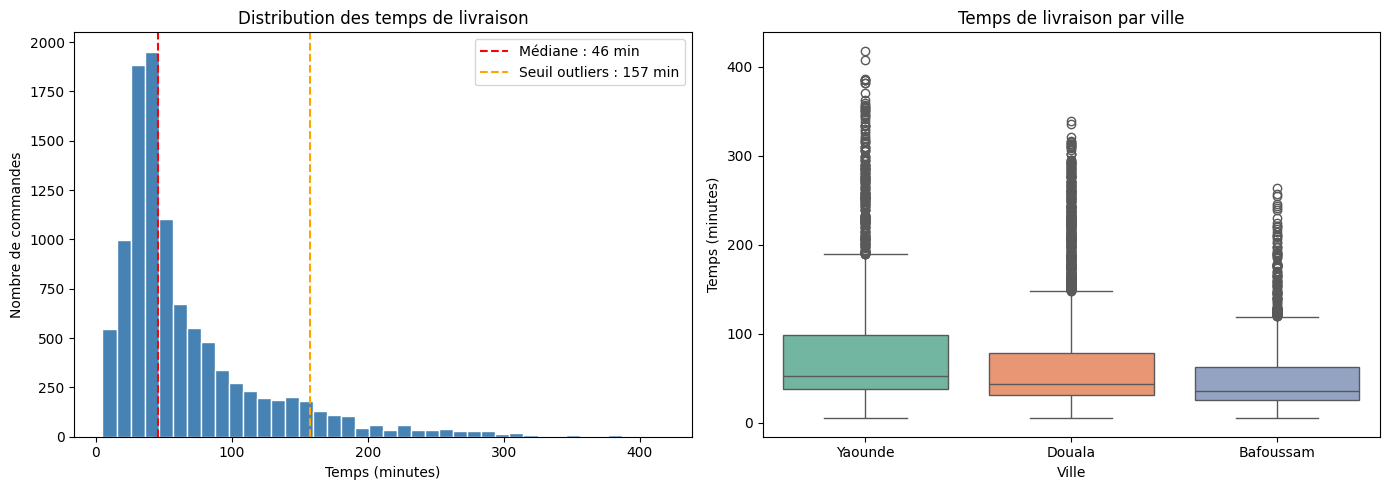

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogramme
axes[0].hist(
    df_orders["delivery_time_min"].dropna(),
    bins=40,
    color="steelblue",
    edgecolor="white"
)
axes[0].axvline(
    df_orders["delivery_time_min"].median(),
    color="red",
    linestyle="--",
    label=f"Médiane : {df_orders['delivery_time_min'].median():.0f} min"
)
axes[0].axvline(
    157.625,
    color="orange",
    linestyle="--",
    label="Seuil outliers : 157 min"
)
axes[0].set_title("Distribution des temps de livraison")
axes[0].set_xlabel("Temps (minutes)")
axes[0].set_ylabel("Nombre de commandes")
axes[0].legend()

# Boxplot par ville
sns.boxplot(
    data=df_orders,
    x="city",
    y="delivery_time_min",
    palette="Set2",
    ax=axes[1]
)
axes[1].set_title("Temps de livraison par ville")
axes[1].set_xlabel("Ville")
axes[1].set_ylabel("Temps (minutes)")

plt.tight_layout()
plt.show()

### Box-Plots Temps de Livraison par ville

C:\Users\pc\AppData\Local\Temp\ipykernel_6656\74085069.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_orders, x="city", y="delivery_time_min", palette=['#1A6B3C','#2A67A6','#F28C28',],


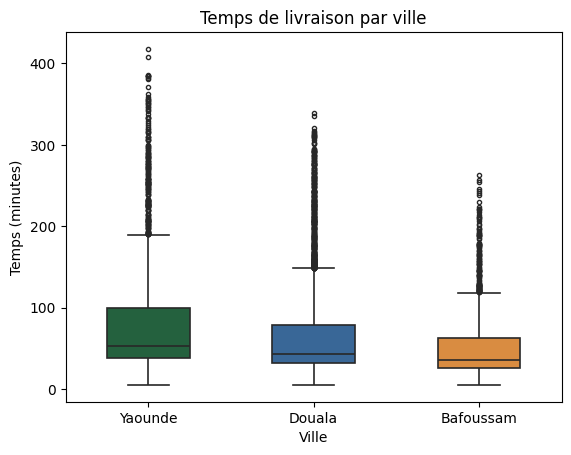

In [31]:
import seaborn as sns

sns.boxplot(data=df_orders, x="city", y="delivery_time_min", palette=['#1A6B3C','#2A67A6','#F28C28',],
width=0.5, fliersize=3, linewidth=1.2)
plt.title("Temps de livraison par ville")
plt.xlabel("Ville")
plt.ylabel("Temps (minutes)")
plt.show()

## Théorème de Bayes


In [17]:
print(df_orders.columns.tolist())

['order_id', 'customer_id', 'order_date', 'delivery_time_min', 'status', 'total_amount_xaf', 'city', 'quartier', 'product_category', 'courier_id', 'order_hour', 'order_day_of_week']


### Extraction des jours et des heures 

In [10]:
df_orders["order_date"] = pd.to_datetime(df_orders["order_date"], format="mixed", dayfirst=True)
df_orders["order_hour"] = df_orders["order_date"].dt.hour
df_orders["order_day_of_week"] = df_orders["order_date"].dt.day_name()

print (df_orders[["order_date", "order_hour", "order_day_of_week"]].head())


           order_date  order_hour order_day_of_week
0 2024-07-06 14:31:00          14          Saturday
1 2024-04-20 18:56:00          18          Saturday
2 2024-10-07 17:37:00          17            Monday
3 2023-03-29 07:48:00           7         Wednesday
4 2024-12-29 08:35:00           8            Sunday


### Probabilité des Livraisons en retard

In [12]:
### Probabilités des Livraison en retard
Nombre_Total_Livraison = len(df_orders)
en_retard = len(df_orders[df_orders["status"] == "en_retard"])
PA = en_retard/Nombre_Total_Livraison
print (PA)

0.19432


In [11]:
### Probabilités des Livraisons Vendredi Soir à Douala
Livr_Vendredi_soir = (
    (df_orders["order_day_of_week"] == "Friday") &
    (df_orders["order_hour"] >= 18) &
    (df_orders["city"] == "Douala")
)

Nombre = len(df_orders[Livr_Vendredi_soir])
PB = Nombre/Nombre_Total_Livraison
print(PB)

0.01944


In [15]:
### Probabilité (Vendredi Soir| Douala)
df_retard = df_orders[df_orders["status"] == "en_retard"]
mask = (
    (df_retard["order_day_of_week"] == "Friday") &
    (df_retard["order_hour"] >= 18) &
    (df_retard["city"] == "Douala")
)
Retard = len (df_retard[mask])
PB_A = Retard/(len(df_retard))
print (PB_A)

0.02181967888019761


In [ ]:
### probabilité qu'une commande soit en retard sachantqu'elle est passée un vendredi soir à Douala
PA_B = (PB_A * PA)/PB

print (PA_B)

0.21810699588477367


### Les t-tests

In [18]:
douala = df_orders[df_orders["city"] == "Douala"]["delivery_time_min"].dropna()
yaounde = df_orders[df_orders["city"] == "Yaounde"]["delivery_time_min"].dropna()

In [19]:
print (len(douala))
print (len(yaounde))

5442
3519


In [20]:
from scipy import stats

stat, p_value = stats.ttest_ind(douala, yaounde)
print(f"p-value : {p_value}")

p-value : 4.376567959637872e-31


### La Matrice de Correlation

In [ ]:
df_customers = pd.DataFrame(load_csv("customers.csv"))

df_merge = df_orders.merge(df_customers, on="customer_id", how="left")
for col in ["total_amount_xaf", "delivery_time_min","loyalty_score", "order_hour"]:
    df_merge[col] = pd.to_numeric(df_merge[col], errors="coerce")

print(df_merge[["total_amount_xaf","delivery_time_min", "loyalty_score", "order_hour"]].corr())

                   total_amount_xaf  delivery_time_min  loyalty_score  \
total_amount_xaf           1.000000           0.003927       0.013771   
delivery_time_min          0.003927           1.000000      -0.009502   
loyalty_score              0.013771          -0.009502       1.000000   
order_hour                -0.004309           0.015417       0.006791   

                   order_hour  
total_amount_xaf    -0.004309  
delivery_time_min    0.015417  
loyalty_score        0.006791  
order_hour           1.000000  


### Graphe de la Matrice


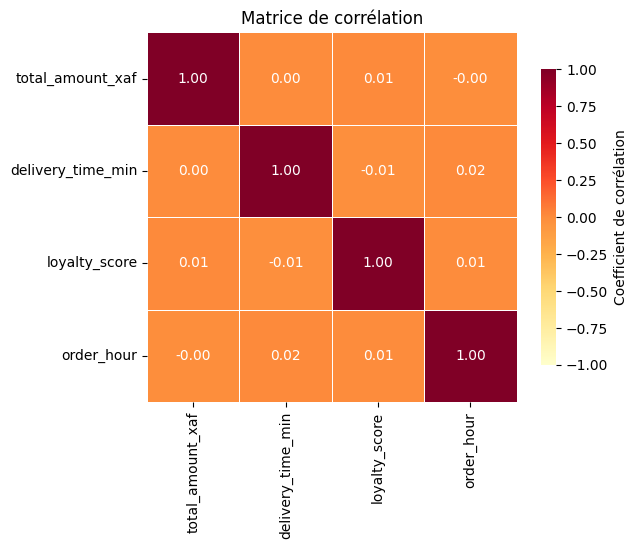

In [24]:
import seaborn as sns
import matplotlib.pyplot as plt

Matrice_Corr = df_merge[["total_amount_xaf", "delivery_time_min","loyalty_score","order_hour"]].corr()

sns.heatmap(Matrice_Corr, annot=True, fmt=".2f", cmap='YlOrRd',
            center=0,
            vmin=-1, vmax=1,
            square=True,
            linewidths=0.5,
            cbar_kws={'label': 'Coefficient de corrélation', 'shrink': 0.8})
plt.title("Matrice de corrélation")
plt.show()

## IQR et OUTLERS

In [2]:
#### Calcul de l'IQR
Q1 = df_orders["delivery_time_min"].quantile(0.25)
Q3 = df_orders["delivery_time_min"].quantile(0.75)
IQR = Q3 - Q1
print (f"Le Premier Quartile est : {Q1}")
print (f"Le Troisième Quartile est : {Q3}")
Borne_Inf = Q1 - 1.5*IQR
Borne_Sup = Q3 + 1.5*IQR
print (f"LInterQuartile Range est {IQR}")
print(Borne_Inf)
print(Borne_Sup)

### Filtrage des Outlers
outliers = df_orders[df_orders["delivery_time_min"] > Borne_Sup]
print(f"Le Nombre d'Outlers est de {len(outliers)}")
print(f"Soit près de {len(outliers) / len(df_orders) * 100:.3f}%")

Le Premier Quartile est : 32.0
Le Troisième Quartile est : 82.25
LInterQuartile Range est 50.25
-43.375
157.625
Le Nombre d'Outlers est de 842
Soit près de 6.736%
